# Part II: Investigating the Vanishing Gradient Problem [20 pts]
Experimentally demonstrate the vanishing gradient problem in deep CNNs and understand how ResNet's architecture mitigates it. You will also explore other key CNN concepts through additional experiments.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support,confusion_matrix
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import glob
import random
import matplotlib.image as mpimg
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


In [6]:
seed = 42
torch.manual_seed(seed)
# torch.cuda.manual_seed(seed)
random.seed(seed)
# np.random.seed(seed)

print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


## Step 1: Create a deeper version of your VGG-16 network (VGG-Deep)

In [7]:
### ADD YOUR CODE HERE ###
class VGG_Deep_Model(nn.Module):
  def __init__(self):
    super(VGG_Deep_Model, self).__init__()

    # Block 1 layers
    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 2 layers
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 3 layers
    self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.conv7 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 4 layers
    self.conv8 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
    self.conv9 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 5 layers
    self.conv11 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
    self.conv12 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)
    self.conv13 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)

    #Additional 4 layers added
    self.conv14 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)
    self.conv15 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)
    self.conv16 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)
    self.conv17 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)

    #FC layers
    self.fc1 = nn.Linear(1024 * 4 * 4, 4096)   # for input 64x64
    self.fc2 = nn.Linear(4096, 4096)
    self.fc3 = nn.Linear(4096, 3)  # 3 is the number of classes


  def forward(self, x):
    #Block 1
    x = nn.ReLU()(self.conv1(x))
    x = self.pool1(nn.ReLU()(self.conv2(x)))

    #Block 2
    x = nn.ReLU()(self.conv3(x))
    x = self.pool2(nn.ReLU()(self.conv4(x)))

    #Block 3
    x = nn.ReLU()(self.conv5(x))
    x = nn.ReLU()(self.conv6(x))
    x = self.pool3(nn.ReLU()(self.conv7(x)))

    #Block 4
    x = nn.ReLU()(self.conv8(x))
    x = nn.ReLU()(self.conv9(x))
    x = self.pool4(nn.ReLU()(self.conv10(x)))

    #Block 5
    x = nn.ReLU()(self.conv11(x))
    x = nn.ReLU()(self.conv12(x))
    x = nn.ReLU()(self.conv13(x))

    #Additional layers
    x = nn.ReLU()(self.conv14(x))
    x = nn.ReLU()(self.conv15(x))
    x = nn.ReLU()(self.conv16(x))
    x = nn.ReLU()(self.conv17(x))

    x = x.view(-1, 1024 * 4 * 4)

    #adding the dropout for the fc layers as in VGG paper
    x = nn.ReLU()(self.fc1(x))
    x = nn.ReLU()(self.fc2(x))
    x = self.fc3(x)

    return x

model_vgg_deep = VGG_Deep_Model().to(device)
print(model_vgg_deep)

VGG_Deep_Model(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv7): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv8): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv9): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv10): Conv2d(51

## Step 2: Training VGG-Deep

Preprocessing of data from part 1

In [8]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])
#Loading the dataset
dataset_dir = "/kaggle/input/cnn-dataset"
full_ds = datasets.ImageFolder(root=dataset_dir, transform=transform)

batch_size = 32
data_loader = DataLoader(full_ds, batch_size=batch_size, shuffle=True, num_workers=2)

data_augmentation = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize to 64x64
    transforms.RandomResizedCrop(64, scale=(0.9, 1.0)),
    transforms.ToTensor(),
])

#preprocessing function
def preprocess(image, label):
    image = transforms.ToPILImage()(image)
    image = data_augmentation(image)
    return image, label

augmented_ds = [(preprocess(image, label)) for image, label in full_ds]

augmented_loader = DataLoader(augmented_ds, batch_size=32, shuffle=True)

print("Preprocessing with resizing completed.")

dataset_count = len(augmented_ds)

#spliting in 7:1.5:1.5
train_size = int(0.7 * dataset_count)
val_size = int(0.15 * dataset_count)
test_size = dataset_count - train_size - val_size

#spliting the dataset
train_ds, val_ds, test_ds = random_split(augmented_ds, [train_size, val_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


Preprocessing with resizing completed.


In [9]:
def model_weight_intialization(model, init_method):
  for layer in model.modules():
    if isinstance(layer, (nn.Conv2d, nn.Linear)):
      if init_method == 'xavier':
        nn.init.xavier_normal_(layer.weight)
        if layer.bias is not None:
          nn.init.zeros_(layer.bias)

      elif init_method == 'he':
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
        if layer.bias is not None:
          nn.init.zeros_(layer.bias)


In [10]:
### ADD YOUR CODE HERE ###
model_weight_intialization(model_vgg_deep,'xavier')
optimizer_vgg_deep = torch.optim.SGD(model_vgg_deep.parameters(), lr=0.01)

scheduler_step_lr_vgg_deep = torch.optim.lr_scheduler.StepLR(optimizer_vgg_deep, step_size=5, gamma=0.1)
loss_function_vgg_deep = nn.CrossEntropyLoss()

epochs = 30

best_model_weight_vgg_deep = None
best_validation_loss_vgg_deep = float('inf')
best_epoch_vgg_deep = 0
train_loss_vgg_deep = []
validation_loss_vgg_deep = []
train_accuracy_vgg_deep = []
validation_accuracy_vgg_deep = []

for epoch in range(epochs):
  model_vgg_deep.train()

  start_time = time.time()

  loop_train_loss_vgg_deep = 0
  correct_train_length_vgg_deep = 0
  total_train_vgg_deep = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_vgg_deep.zero_grad()

    outputs = model_vgg_deep(inputs)

    loss = loss_function_vgg_deep(outputs, labels)
    loss.backward()
    optimizer_vgg_deep.step()

    _, predicted_vgg_deep = torch.max(outputs, 1)
    total_train_vgg_deep += labels.size(0)
    correct_train_length_vgg_deep += (predicted_vgg_deep == labels).sum().item()

    loop_train_loss_vgg_deep += loss.item()

  scheduler_step_lr_vgg_deep.step() #learning rate scheduler

  #training accuracy and loss
  train_accuracy_value_vgg_deep = 100 * correct_train_length_vgg_deep / total_train_vgg_deep
  train_loss_vgg_deep.append(loop_train_loss_vgg_deep / len(train_loader))
  train_accuracy_vgg_deep.append(train_accuracy_value_vgg_deep)

  #Validation
  model_vgg_deep.eval()
  loop_val_loss_vgg_deep = 0
  correct_val_vgg_deep = 0
  total_val_vgg_deep = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_vgg_deep(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_vgg_deep(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_vgg_deep = torch.max(val_outputs, 1)

      total_val_vgg_deep += val_labels.size(0)
      correct_val_vgg_deep += (predicted_vgg_deep == val_labels).sum().item()

      loop_val_loss_vgg_deep += val_loss.item()

  #validation accuracy and loss
  val_accuracy_vgg_deep = 100 * correct_val_vgg_deep / total_val_vgg_deep
  validation_loss_vgg_deep.append(loop_val_loss_vgg_deep / len(val_loader))
  validation_accuracy_vgg_deep.append(val_accuracy_vgg_deep)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_vgg_deep[-1]:.4f}, Train Accuracy: {train_accuracy_vgg_deep[-1]:.2f}%, "
    f"Val Loss: {validation_loss_vgg_deep[-1]:.4f}, Val Accuracy: {validation_accuracy_vgg_deep[-1]:.2f}%")

  end_time = time.time()
  training_time_vgg_deep = end_time - start_time
  print(f"Training Time: {training_time_vgg_deep:.2f} seconds")


Epoch [1/30], Train Loss: 1.0982, Train Accuracy: 34.70%, Val Loss: 1.0969, Val Accuracy: 45.27%
Training Time: 35.20 seconds
Epoch [2/30], Train Loss: 1.0735, Train Accuracy: 50.22%, Val Loss: 0.9919, Val Accuracy: 51.64%
Training Time: 34.35 seconds
Epoch [3/30], Train Loss: 0.8532, Train Accuracy: 59.92%, Val Loss: 0.8578, Val Accuracy: 59.40%
Training Time: 34.34 seconds
Epoch [4/30], Train Loss: 0.7379, Train Accuracy: 67.33%, Val Loss: 0.6941, Val Accuracy: 69.27%
Training Time: 34.34 seconds
Epoch [5/30], Train Loss: 0.6577, Train Accuracy: 72.80%, Val Loss: 0.5829, Val Accuracy: 76.38%
Training Time: 34.37 seconds
Epoch [6/30], Train Loss: 0.5403, Train Accuracy: 78.36%, Val Loss: 0.5303, Val Accuracy: 78.42%
Training Time: 34.36 seconds
Epoch [7/30], Train Loss: 0.5146, Train Accuracy: 79.53%, Val Loss: 0.5107, Val Accuracy: 78.89%
Training Time: 34.36 seconds
Epoch [8/30], Train Loss: 0.4974, Train Accuracy: 80.20%, Val Loss: 0.5042, Val Accuracy: 79.31%
Training Time: 34.35 

In [11]:
# Test phase
model_vgg_deep.eval()
correct_test_length_vgg_deep = 0
total_test_vgg_deep = 0
y_true_vgg_deep = []
y_pred_vgg_deep = []

# test_loss = []
test_accuracy_vgg_deep =[]
test_total_loss_vgg_deep = 0.0
predicted_list_vgg_deep = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_vgg_deep(inputs)

    labels = labels.view(-1)
    test_total_loss_vgg_deep += loss_function_vgg_deep(outputs, labels).item()

    _, predicted_vgg_deep = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_vgg_deep += labels.size(0)
    correct_test_length_vgg_deep += (predicted_vgg_deep == labels).sum().item()

    y_true_vgg_deep.extend(labels.cpu().numpy())
    y_pred_vgg_deep.extend(predicted_vgg_deep.cpu().numpy())
    predicted_list_vgg_deep.extend(predicted_test_probs.cpu().numpy())


y_pred_vgg_deep = np.array(y_pred_vgg_deep)
y_true_vgg_deep = np.array(y_true_vgg_deep)
predicted_list_vgg_deep = np.array(predicted_list_vgg_deep)

test_accuracy_vgg_deep = 100 * (correct_test_length_vgg_deep / total_test_vgg_deep)
print(f"Test Accuracy: {test_accuracy_vgg_deep:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_vgg_deep, y_pred_vgg_deep, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_vgg_deep = test_total_loss_vgg_deep /len(test_loader)

test_accuracies_plot_vgg_deep = [test_accuracy_vgg_deep] * epochs
test_loss_plot_vgg_deep = [test_loss_vgg_deep] * epochs

Test Accuracy: 82.11%
Precision: 0.8208, Recall: 0.8211, F1: 0.8209


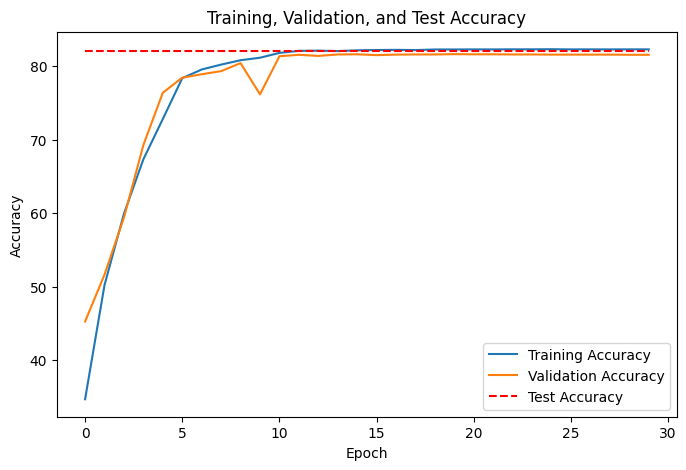

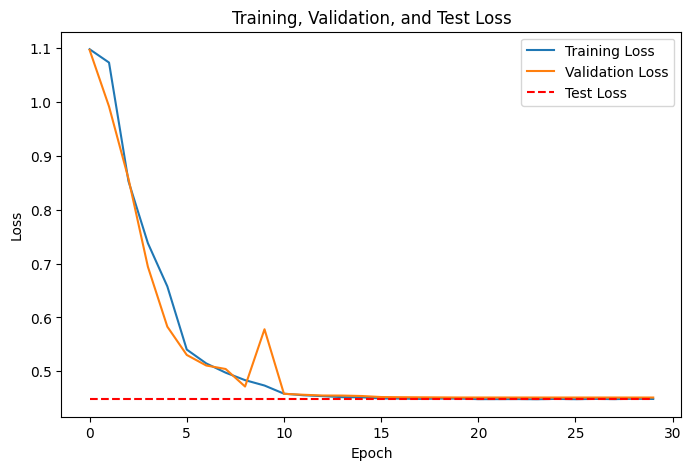

In [12]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_vgg_deep, label='Training Accuracy')
plt.plot(validation_accuracy_vgg_deep, label='Validation Accuracy')
plt.plot(test_accuracies_plot_vgg_deep, label='Test Accuracy', linestyle='--', color='red')
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_vgg_deep, label='Training Loss')
plt.plot(validation_loss_vgg_deep, label='Validation Loss')
plt.plot(test_loss_plot_vgg_deep, label='Test Loss', linestyle='--', color='red')
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

<span style='color:green'>### YOUR ANSWER ###</span> 

Here we can clearly see that increasing the depth of the base VGG model without dropouts brings the accuracy down. When comparing the graphs from orginial vgg model and the current vgg deep model we can see the up and down spikes in the VGG deep graph.
![VGG Original Accuracy Graph](sgd_xavier_accuracy.png)

![VGG Original Loss Graph](sgd_xavier_loss.png)

Some reasons for the performance is the depth of the network which is making it harder to generalize. And not using dropout could cause overfitting too which the small spikes in vgg deep graph we can see. And if we also can see that the vgg deep training accuracy has a hike compared to vgg original where the growth is steady and gradual. Also the validation accuracy does increase in the beginning itself in vgg original but in vgg deep we see even though steady improvement it drops and picks up around 80%  showing that it could be overfitting.

## Step 3: Gradient analysis

**- Track the average L2 norm of the gradients in each convolutional layer using PyTorch hooks.**

In [13]:
### ADD YOUR CODE HERE ###
# Store gradient norms for analysis
gradients = {}

# Define the gradient hook
def gradient_hook(module, grad_input, grad_output):
    grad_norm = grad_output[0].norm(p=2).item()
    if module in gradients:
        gradients[module].append(grad_norm)
    else:
        gradients[module] = [grad_norm]

# # Register hooks on each convolutional layer
# for layer in model.children():
#     if isinstance(layer, nn.Conv2d):
#         layer.weight.register_full_backward_hook(gradient_hook)

def compute_avg_gradient_norm():
    avg_gradients = {layer: sum(norms) / len(norms) for layer, norms in gradients.items()}
    return avg_gradients


In [14]:
### ADD YOUR CODE HERE ###
model_grad_hook = VGG_Deep_Model().to(device)
model_weight_intialization(model_grad_hook,'xavier')
optimizer_grad_hook = torch.optim.SGD(model_grad_hook.parameters(), lr=0.01)

scheduler_step_lr_grad_hook = torch.optim.lr_scheduler.StepLR(optimizer_grad_hook, step_size=5, gamma=0.1)
loss_function_grad_hook = nn.CrossEntropyLoss()

epochs = 30

# best_model_weight_grad_hook = None
# best_validation_loss_grad_hook = float('inf')
# best_epoch_grad_hook = 0
train_loss_grad_hook = []
validation_loss_grad_hook = []
train_accuracy_grad_hook = []
validation_accuracy_grad_hook = []

# Register hooks on each convolutional layer
for layer in model_grad_hook.modules():
    if isinstance(layer, nn.Conv2d):
        layer.register_full_backward_hook(gradient_hook)


for epoch in range(epochs):
  model_grad_hook.train()

  start_time = time.time()

  loop_train_loss_grad_hook = 0
  correct_train_length_grad_hook = 0
  total_train_grad_hook = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_grad_hook.zero_grad()

    outputs = model_grad_hook(inputs)

    loss = loss_function_grad_hook(outputs, labels)
    loss.backward()
    optimizer_grad_hook.step()

    _, predicted_grad_hook = torch.max(outputs, 1)
    total_train_grad_hook += labels.size(0)
    correct_train_length_grad_hook += (predicted_grad_hook == labels).sum().item()

    loop_train_loss_grad_hook += loss.item()

  scheduler_step_lr_grad_hook.step() #learning rate scheduler

  #training accuracy and loss
  train_accuracy_value_grad_hook = 100 * correct_train_length_grad_hook / total_train_grad_hook
  train_loss_grad_hook.append(loop_train_loss_grad_hook / len(train_loader))
  train_accuracy_grad_hook.append(train_accuracy_value_grad_hook)

  # #Validation
  # model_grad_hook.eval()
  # loop_val_loss_grad_hook = 0
  # correct_val_grad_hook = 0
  # total_val_grad_hook = 0

  # with torch.no_grad():
  #   for val_inputs, val_labels in val_loader:
  #     val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
  #     val_outputs = model_grad_hook(val_inputs)

  #     val_labels = val_labels.view(-1)
  #     val_loss = loss_function_grad_hook(val_outputs, val_labels)

  #     # Track validation accuracy
  #     _, predicted_grad_hook = torch.max(val_outputs, 1)

  #     total_val_grad_hook += val_labels.size(0)
  #     correct_val_grad_hook += (predicted_grad_hook == val_labels).sum().item()

  #     loop_val_loss_grad_hook += val_loss.item()

  # #validation accuracy and loss
  # val_accuracy_grad_hook = 100 * correct_val_grad_hook / total_val_grad_hook
  # validation_loss_grad_hook.append(loop_val_loss_grad_hook / len(val_loader))
  # validation_accuracy_grad_hook.append(val_accuracy_grad_hook)

  print(f"Epoch [{epoch+1}/{epochs}], "
  f"Train Loss: {train_loss_grad_hook[-1]:.4f}, Train Accuracy: {train_accuracy_grad_hook[-1]:.2f}%,")
        # f"Val Loss: {validation_loss_grad_hook[-1]:.4f}, Val Accuracy: {validation_accuracy_grad_hook[-1]:.2f}%")


  end_time = time.time()
  training_time_grad_hook = end_time - start_time
  print(f"Training Time: {training_time_grad_hook:.2f} seconds")


avg_gradients = compute_avg_gradient_norm()
print(avg_gradients)

Epoch [1/30], Train Loss: 1.0984, Train Accuracy: 34.60%,
Training Time: 33.37 seconds
Epoch [2/30], Train Loss: 1.0857, Train Accuracy: 46.71%,
Training Time: 33.35 seconds
Epoch [3/30], Train Loss: 0.8846, Train Accuracy: 58.52%,
Training Time: 33.32 seconds
Epoch [4/30], Train Loss: 0.7735, Train Accuracy: 65.57%,
Training Time: 33.33 seconds
Epoch [5/30], Train Loss: 0.6567, Train Accuracy: 72.47%,
Training Time: 33.31 seconds
Epoch [6/30], Train Loss: 0.5305, Train Accuracy: 78.50%,
Training Time: 33.31 seconds
Epoch [7/30], Train Loss: 0.5094, Train Accuracy: 79.44%,
Training Time: 33.32 seconds
Epoch [8/30], Train Loss: 0.4942, Train Accuracy: 79.81%,
Training Time: 33.37 seconds
Epoch [9/30], Train Loss: 0.4878, Train Accuracy: 80.20%,
Training Time: 33.38 seconds
Epoch [10/30], Train Loss: 0.4796, Train Accuracy: 80.49%,
Training Time: 33.36 seconds
Epoch [11/30], Train Loss: 0.4652, Train Accuracy: 81.20%,
Training Time: 33.37 seconds
Epoch [12/30], Train Loss: 0.4616, Train 

**- Create a plot showing the average gradient norm for each convolutional layer over time.**

In [21]:
# ### ADD YOUR CODE HERE ###
# layers = list(gradients.keys())
# gradient_vals = list(gradients.values())

# plt.figure(figsize=(12, 6))
# for item, grad in enumerate(gradient_vals):
#     plt.plot(grad, label=layers[item])

# plt.xlabel('Epochs')
# plt.ylabel('Norm Value of Gradients')
# plt.title('Gradient Norms for Each Convolutional Layer')
# plt.legend()
# plt.grid(True)
# plt.show()

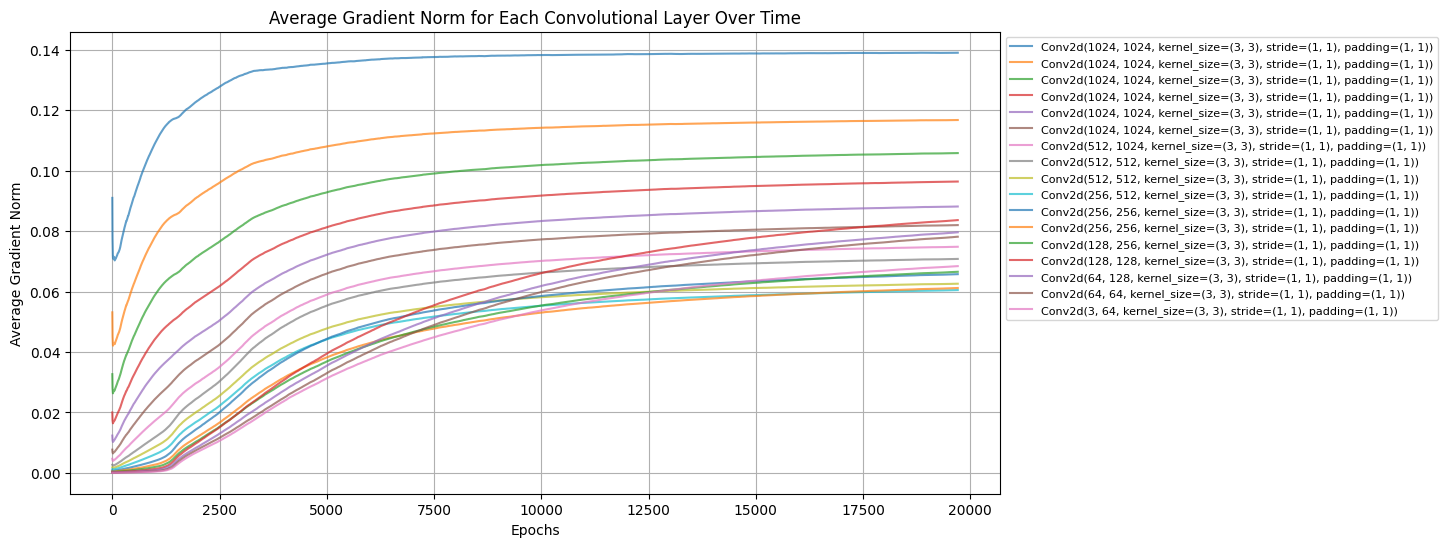

In [16]:
epochs = list(range(len(next(iter(gradients.values())))))

# First Plot: Gradient Norms for All Convolutional Layers
plt.figure(figsize=(12, 6))

for layer, norms in gradients.items():
    avg_norms = [sum(norms[:i+1]) / (i+1) for i in range(len(norms))]  # Compute running average
    plt.plot(epochs, avg_norms, alpha=0.7, label=str(layer))  # Adjust alpha for better visibility

plt.xlabel("Epochs")
plt.ylabel("Average Gradient Norm")
plt.title("Average Gradient Norm for Each Convolutional Layer Over Time")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
plt.grid(True)
plt.show()



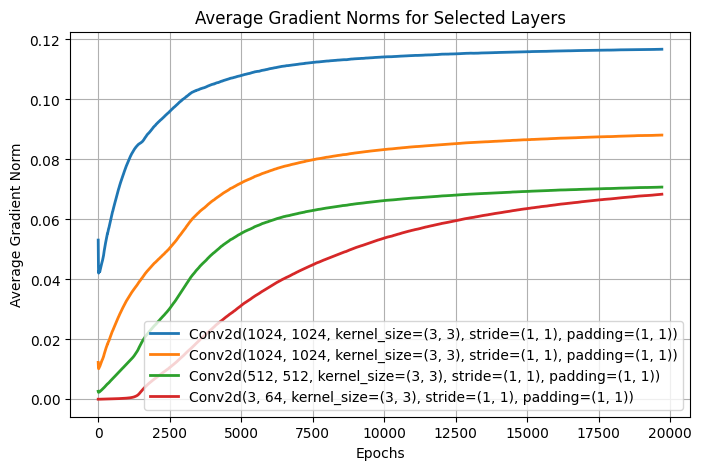

In [17]:
#Second Plot of just the selected Layers (2nd, 5th, 8th, and the deepest)
selected_layers = [
    list(gradients.keys())[1],  # 2nd layer
    list(gradients.keys())[4],  # 5th layer
    list(gradients.keys())[7],  # 8th layer
    list(gradients.keys())[-1]  # Deepest layer
]

plt.figure(figsize=(8, 5))

for layer in selected_layers:
    avg_norms = [sum(gradients[layer][:i+1]) / (i+1) for i in range(len(gradients[layer]))]
    plt.plot(epochs, avg_norms, label=str(layer), linewidth=2)

plt.xlabel("Epochs")
plt.ylabel("Average Gradient Norm")
plt.title("Average Gradient Norms for Selected Layers")
plt.legend()
plt.grid(True)
plt.show()

**- Create a separate plot showing the gradient norms for a subset of layers.**

In [22]:
# ### ADD YOUR CODE HERE ###
# layers = ['Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))',
#           'Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))',
#           'Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))',
#           'Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))']

# layer_gradients = {layer: gradients[layer] for layer in layers if layer in gradients}

# plt.figure(figsize=(12, 6))
# for layer, grad in layer_gradients.items():
#     plt.plot(grad, label=layer)

# plt.xlabel('Epochs')
# plt.ylabel('Gradient Norm')
# plt.title('Gradient Norms for Selected Layers')
# plt.legend()
# plt.grid(True)
# plt.show()

<span style='color:green'>### YOUR ANSWER ###</span>

As we can see from the graphs above, the first graph shows the vanishing gradient problem where we can see that the layers have smaller gradient norms. However I do see that the deepest layer still has a value slightly bigger than the lowest layer. Now one reason is maybe the use of xavier weight initialization that maintains the gradient values.
Similarly the second grpah also does not exactly show the vanishing gradinet as much. We can see a slight decrease in the values in the middle layer but then the deeper layers have higher values.

We can say that gradients are decreasing/reducing but not vanishing completely. And some reasons for this is the use of Xavier intialization. 

In this case we could say that basicially we are solving the issue of vanishing gradients.

## Step 4: Comparison with VGG-16 and ResNet-18

**- Compare the training curves (loss and accuracy vs. epoch) of VGG-Deep, VGG-16, and ResNet-18.**

#### Orginial VGG-16: This is the best vgg model with batch norm and batch size 64 using Xavier intialization and Adam optimizer.

In [19]:
### ADD YOUR CODE HERE ###
class VGG_CNN_Model_Batch_Norm(nn.Module):
  def __init__(self):
    super(VGG_CNN_Model_Batch_Norm, self).__init__()

    # Block 1 layers
    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(64)
    self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 2 layers
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)
    self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(128)
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 3 layers
    self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.bn5 = nn.BatchNorm2d(256)
    self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.bn6 = nn.BatchNorm2d(256)
    self.conv7 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.bn7 = nn.BatchNorm2d(256)
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 4 layers
    self.conv8 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
    self.bn8 = nn.BatchNorm2d(512)
    self.conv9 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn9 = nn.BatchNorm2d(512)
    self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn10 = nn.BatchNorm2d(512)
    self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

    #Block 5 layers
    self.conv11 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn11 = nn.BatchNorm2d(512)
    self.conv12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn12 = nn.BatchNorm2d(512)
    self.conv13 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn13 = nn.BatchNorm2d(512)

    #FC layers
    self.fc1 = nn.Linear(512 * 4 * 4, 4096)   # for input 64x64
    self.fc2 = nn.Linear(4096, 4096)
    self.fc3 = nn.Linear(4096, 3)  # 3 is the number of classes

    # dropout as used in VGG model for regularization
    self.dropout = nn.Dropout(p=0.5)

  def forward(self, x):
    #Block 1
    x = nn.ReLU()(self.bn1(self.conv1(x)))
    x = self.pool1(nn.ReLU()(self.bn2(self.conv2(x))))

    #Block 2
    x = nn.ReLU()(self.bn3(self.conv3(x)))
    x = self.pool2(nn.ReLU()(self.bn4(self.conv4(x))))

    #Block 3
    x = nn.ReLU()(self.bn5(self.conv5(x)))
    x = nn.ReLU()(self.bn6(self.conv6(x)))
    x = self.pool3(nn.ReLU()(self.bn7(self.conv7(x))))

    #Block 4
    x = nn.ReLU()(self.bn8(self.conv8(x)))
    x = nn.ReLU()(self.bn9(self.conv9(x)))
    x = self.pool4(nn.ReLU()(self.bn10(self.conv10(x))))

    #Block 5
    x = nn.ReLU()(self.bn11(self.conv11(x)))
    x = nn.ReLU()(self.bn12(self.conv12(x)))
    x = nn.ReLU()(self.bn13(self.conv13(x)))

    x = x.view(-1, 512 * 4 *4)

    #adding the dropout for the fc layers as in VGG paper
    x = self.dropout(nn.ReLU()(self.fc1(x)))
    x = self.dropout(nn.ReLU()(self.fc2(x)))
    x = self.fc3(x)

    return x


In [25]:
### ADD YOUR CODE HERE ###

# this is the train loop for VGG original best improved model

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

original_best_vgg = VGG_CNN_Model_Batch_Norm().to(device)

#please load the weights file before loading
loading_best_vgg = torch.load('/kaggle/input/vgg-and-resnet-modesls/pytorch/default/1/a1_ra65_hsingh47_vgg_model.pt',weights_only=True)

original_best_vgg.load_state_dict(loading_best_vgg)

# model_weight_intialization(original_best_vgg,'xavier')
optimizer_best_vgg = torch.optim.Adam(original_best_vgg.parameters(), lr=0.0005, weight_decay=1e-5)

scheduler_step_lr_best_vgg = torch.optim.lr_scheduler.StepLR(optimizer_best_vgg, step_size=5, gamma=0.1)
loss_function_best_vgg = nn.CrossEntropyLoss()

epochs = 30

train_loss_best_vgg = []
train_accuracy_best_vgg = []


for epoch in range(epochs):

  original_best_vgg.train()

  # start_time = time.time()

  loop_train_loss_best_vgg = 0
  correct_train_length_best_vgg = 0
  total_train_best_vgg = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_best_vgg.zero_grad()

    outputs = original_best_vgg(inputs)

    loss = loss_function_best_vgg(outputs, labels)
    loss.backward()
    optimizer_best_vgg.step()

    _, predicted_best_vgg = torch.max(outputs, 1)
    total_train_best_vgg += labels.size(0)
    correct_train_length_best_vgg += (predicted_best_vgg == labels).sum().item()

    loop_train_loss_best_vgg += loss.item()

  scheduler_step_lr_best_vgg.step()

  #training accuracy and loss
  train_accuracy_value_best_vgg = 100 * correct_train_length_best_vgg / total_train_best_vgg
  train_loss_best_vgg.append(loop_train_loss_best_vgg / len(train_loader))
  train_accuracy_best_vgg.append(train_accuracy_value_best_vgg)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_best_vgg[-1]:.4f}, Train Accuracy: {train_accuracy_best_vgg[-1]:.2f}%, ")
    # f"Val Loss: {validation_loss_batch_norm[-1]:.4f}, Val Accuracy: {validation_accuracy_batch_norm[-1]:.2f}%")

  # end_time = time.time()
  # training_time_best_vgg = end_time - start_time
  # print(f"Training Time: {training_time_best_vgg:.2f} seconds")



Epoch [1/30], Train Loss: 0.7470, Train Accuracy: 83.28%, 
Epoch [2/30], Train Loss: 0.3582, Train Accuracy: 87.83%, 
Epoch [3/30], Train Loss: 0.3330, Train Accuracy: 88.86%, 
Epoch [4/30], Train Loss: 0.2878, Train Accuracy: 90.10%, 
Epoch [5/30], Train Loss: 0.2864, Train Accuracy: 90.11%, 
Epoch [6/30], Train Loss: 0.3246, Train Accuracy: 90.04%, 
Epoch [7/30], Train Loss: 0.2321, Train Accuracy: 91.48%, 
Epoch [8/30], Train Loss: 0.2158, Train Accuracy: 91.99%, 
Epoch [9/30], Train Loss: 0.2055, Train Accuracy: 92.66%, 
Epoch [10/30], Train Loss: 0.1960, Train Accuracy: 92.77%, 
Epoch [11/30], Train Loss: 0.1805, Train Accuracy: 93.35%, 
Epoch [12/30], Train Loss: 0.1864, Train Accuracy: 93.28%, 
Epoch [13/30], Train Loss: 0.1752, Train Accuracy: 93.45%, 
Epoch [14/30], Train Loss: 0.1816, Train Accuracy: 93.52%, 
Epoch [15/30], Train Loss: 0.1801, Train Accuracy: 93.56%, 
Epoch [16/30], Train Loss: 0.1727, Train Accuracy: 93.66%, 
Epoch [17/30], Train Loss: 0.1709, Train Accuracy

#### Orginial Resnet-18: The best model of Resnet with same optimizer of Adam and using xavier weight intialization, and batch norm is already part of resnet base setup.

In [26]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=1000):
        super(ResNet18, self).__init__()
        self.in_channels = 64

        #initial convolution, batch norm, activation, and max pooling
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        #built residual layers using the ResidualBlock
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        #adaptive average pooling and fully connected layer
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Classification head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


In [27]:
# this is the train loop for Resnet original improved model

# batch_size = 64
# train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

model_adam_resnet_xavier = ResNet18(num_classes=3).to(device)

loading_adam_resnet_xavier = torch.load('/kaggle/input/vgg-and-resnet-modesls/pytorch/default/1/a1_ra65_hsingh47_resnet_model_adam_xavier.pt',weights_only=True)

model_adam_resnet_xavier.load_state_dict(loading_adam_resnet_xavier)

# model_weight_intialization(model_early_stopping_resnet,'xavier')
optimizer_adam_resnet_xavier = torch.optim.Adam(model_adam_resnet_xavier.parameters(), lr=0.0001, weight_decay=5e-4)

scheduler_step_lr_adam_resnet_xavier = torch.optim.lr_scheduler.StepLR(optimizer_adam_resnet_xavier, step_size=5, gamma=0.1)
loss_function_adam_resnet_xavier = nn.CrossEntropyLoss()


epochs = 30

best_validation_loss_adam_resnet_xavier = float('inf')
best_epoch_adam_resnet_xavier = 0
train_loss_adam_resnet_xavier = []
validation_loss_adam_resnet_xavier = []
train_accuracy_adam_resnet_xavier = []
validation_accuracy_adam_resnet_xavier = []

for epoch in range(epochs):
  model_adam_resnet_xavier.train()

  start_time = time.time()

  loop_train_loss_adam_resnet_xavier = 0
  correct_train_length_adam_resnet_xavier = 0
  total_train_adam_resnet_xavier = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_adam_resnet_xavier.zero_grad()

    outputs = model_adam_resnet_xavier(inputs)

    loss = loss_function_adam_resnet_xavier(outputs, labels)
    loss.backward()
    optimizer_adam_resnet_xavier.step()

    _, predicted_adam_resnet_xavier = torch.max(outputs, 1)
    total_train_adam_resnet_xavier += labels.size(0)
    correct_train_length_adam_resnet_xavier += (predicted_adam_resnet_xavier == labels).sum().item()

    loop_train_loss_adam_resnet_xavier += loss.item()

  scheduler_step_lr_adam_resnet_xavier.step()

  #training accuracy and loss
  train_accuracy_value_adam_resnet_xavier = 100 * correct_train_length_adam_resnet_xavier / total_train_adam_resnet_xavier
  train_loss_adam_resnet_xavier.append(loop_train_loss_adam_resnet_xavier / len(train_loader))
  train_accuracy_adam_resnet_xavier.append(train_accuracy_value_adam_resnet_xavier)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_adam_resnet_xavier[-1]:.4f}, Train Accuracy: {train_accuracy_adam_resnet_xavier[-1]:.2f}%, ")
 



Epoch [1/30], Train Loss: 0.2217, Train Accuracy: 92.03%, 
Epoch [2/30], Train Loss: 0.1156, Train Accuracy: 95.74%, 
Epoch [3/30], Train Loss: 0.0690, Train Accuracy: 97.42%, 
Epoch [4/30], Train Loss: 0.0580, Train Accuracy: 97.75%, 
Epoch [5/30], Train Loss: 0.0450, Train Accuracy: 98.35%, 
Epoch [6/30], Train Loss: 0.0162, Train Accuracy: 99.51%, 
Epoch [7/30], Train Loss: 0.0082, Train Accuracy: 99.90%, 
Epoch [8/30], Train Loss: 0.0044, Train Accuracy: 99.91%, 
Epoch [9/30], Train Loss: 0.0028, Train Accuracy: 99.93%, 
Epoch [10/30], Train Loss: 0.0016, Train Accuracy: 99.96%, 
Epoch [11/30], Train Loss: 0.0015, Train Accuracy: 99.96%, 
Epoch [12/30], Train Loss: 0.0010, Train Accuracy: 99.98%, 
Epoch [13/30], Train Loss: 0.0008, Train Accuracy: 99.99%, 
Epoch [14/30], Train Loss: 0.0005, Train Accuracy: 100.00%, 
Epoch [15/30], Train Loss: 0.0007, Train Accuracy: 99.99%, 
Epoch [16/30], Train Loss: 0.0006, Train Accuracy: 99.99%, 
Epoch [17/30], Train Loss: 0.0009, Train Accurac

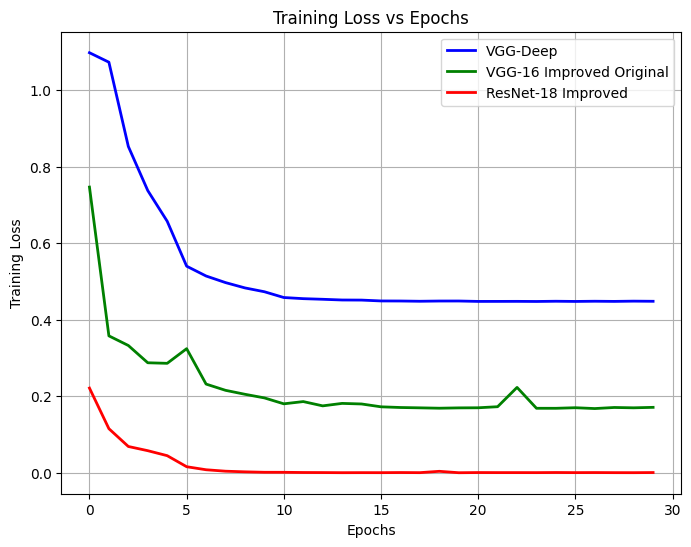

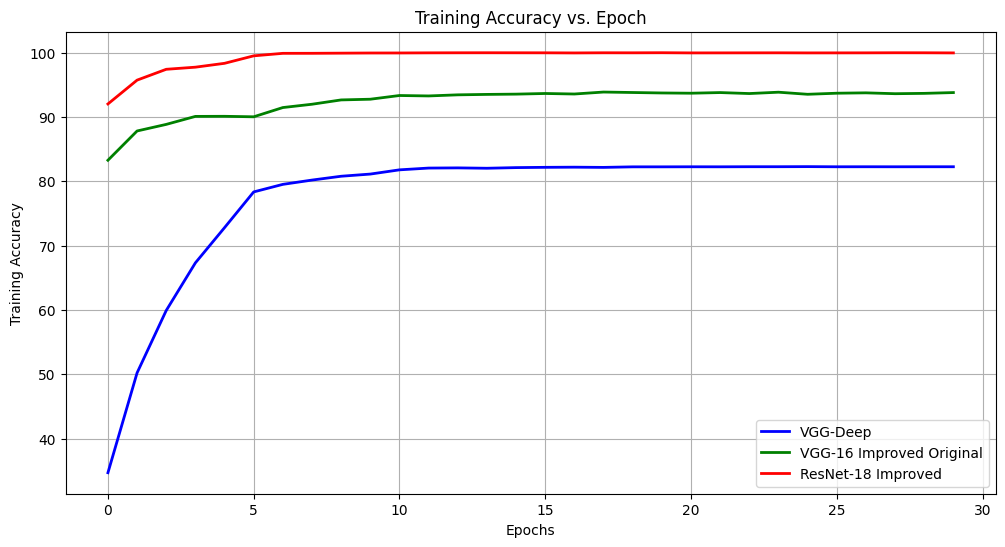

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(train_loss_vgg_deep, label='VGG-Deep', color='blue', linewidth=2)
plt.plot(train_loss_best_vgg, label='VGG-16 Improved Original', color='green', linewidth=2)
plt.plot(train_loss_adam_resnet_xavier, label='ResNet-18 Improved', color='red', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Training Loss vs Epochs')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(train_accuracy_vgg_deep, label='VGG-Deep', color='blue', linewidth=2)
plt.plot(train_accuracy_best_vgg, label='VGG-16 Improved Original', color='green', linewidth=2)
plt.plot(train_accuracy_adam_resnet_xavier, label='ResNet-18 Improved', color='red', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy vs. Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

As we can see VGG deep has compartively higher loss than both VGG original abd Resnet architectures and that VGG-Deep the loss value falls very quickly showing that it might be memorzing. Similarly the training accuarcy is much better for VGG original and Resnet where both have values close to 85% and more and has steady and stable increase. And VGG-Deep compartivley has a huge spike in the training values showing that there are chances of overfitting in VGG-Deep. 

In our comparsion its also important to note the use of different optimizer in VGG-Deep compared to the setup of VGG and Resnet which affects the training too. VGG-Deep uses SGD  whereas the other use Adam and also include other regularizations that help wiht the trianing values. 

This shows that even without the regurlatization the VGG-Deep with more layers is learning and also during trying to prevent the issue of vanishing gradients.

**- Discuss how ResNet’s residual connections impact the gradient flow compared to VGG-Deep.**

<span style='color:green'>### YOUR ANSWER ###</span>

In Resnet architecure it specifically has methods to reduce the vanishing gradient problem. In VGG-deep it has a lot more layers and as it does bacpropggation it becomes difficult to calculate as the layer increases. 

In Resnet it uses the residual blocks where there is way the input layer bypasses the middle changes and is added directly to the output where it learns the difference between the input and expected output. It is that skip conncetion techniue during back propagation that has the impact on the gradient norm values.
In VGG as the depth increases then we need to add dropout or batch normalization to be able to make sure the performance does not decrease.  Whereas Resnet can maintian it performace as the network increases because of its resuidal connections as it is less sentive to depth of layers and hence is more efficient in learning.

## Step 5: Investigate and analyze more setups

- Select any THREE experiments to investigate and analyze.\\
  1. Kenerel Sizes
  2. 1x1 Convolutions
  3. MaxPool vs. AvgPool


### Experiment 1 : Checking the impact of Kernel size

In [ ]:
### ADD YOUR CODE HERE ###
class VGG_Small_network(nn.Module):
    def __init__(self, kernel_size=3):
        super(VGG_Small_network, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=kernel_size, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=kernel_size, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, stride=1, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=kernel_size, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, 3)

    def forward(self, x):

        x = nn.ReLU()(self.conv1(x))
        x = self.pool1(nn.ReLU()(self.conv2(x)))

        x = nn.ReLU()(self.conv3(x))
        x = self.pool2(nn.ReLU()(self.conv4(x)))

        # print(x.shape)

        x = x.view(-1, 128 * 16 * 16)

        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
from torch.utils.data import Subset, SubsetRandomSampler

#loading a subset of the data
transform = transforms.Compose([
    transforms.Resize((64, 64)),  #Resize to 64x64
    transforms.ToTensor(),
])

whole_ds = datasets.ImageFolder(root=dataset_dir, transform=transform)

subset = []
for item in range(3):
    class_vals = [i for i, target in enumerate(whole_ds.targets) if target == item]
    subset.extend(class_vals[:1000])  #first 1000 images from each class

train_subset = Subset(whole_ds, subset)

small_train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)


Setup with kernel size 3

In [ ]:
model_kernel_3 = VGG_Small_network(kernel_size=3).to(device)
model_weight_intialization(model_kernel_3,'xavier')
optimizer_kernel_3 = torch.optim.SGD(model_kernel_3.parameters(), lr=0.01)
scheduler_step_lr_kernel_3 = torch.optim.lr_scheduler.StepLR(optimizer_kernel_3, step_size=5, gamma=0.1)
loss_function_kernel_3 = nn.CrossEntropyLoss()

epochs = 10

train_loss_kernel_3 = []
validation_loss_kernel_3 = []
train_accuracy_kernel_3 = []
validation_accuracy_kernel_3 = []

for epoch in range(epochs):
  model_kernel_3.train()

  start_time = time.time()

  loop_train_loss_kernel_3 = 0
  correct_train_length_kernel_3 = 0
  total_train_kernel_3 = 0

  for inputs, labels in small_train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_kernel_3.zero_grad()

    outputs = model_kernel_3(inputs)

    loss = loss_function_kernel_3(outputs, labels)
    loss.backward()
    optimizer_kernel_3.step()

    _, predicted_kernel_3 = torch.max(outputs, 1)
    total_train_kernel_3 += labels.size(0)
    correct_train_length_kernel_3 += (predicted_kernel_3 == labels).sum().item()

    loop_train_loss_kernel_3 += loss.item()

  scheduler_step_lr_kernel_3.step() #learning rate scheduler

  #training accuracy and loss
  train_accuracy_value_kernel_3 = 100 * correct_train_length_kernel_3 / total_train_kernel_3
  train_loss_kernel_3.append(loop_train_loss_kernel_3 / len(train_loader))
  train_accuracy_kernel_3.append(train_accuracy_value_kernel_3)


  print(f"Epoch [{epoch+1}/{epochs}], "
  f"Train Loss: {train_loss_kernel_3[-1]:.4f}, Train Accuracy: {train_accuracy_kernel_3[-1]:.2f}%,")
        # f"Val Loss: {validation_loss_kernel_3[-1]:.4f}, Val Accuracy: {validation_accuracy_kernel_3[-1]:.2f}%")

  end_time = time.time()
  training_time_kernel_3 = end_time - start_time
  print(f"Training Time: {training_time_kernel_3:.2f} seconds")


Epoch [1/10], Train Loss: 0.2917, Train Accuracy: 50.60%,
Training Time: 4.15 seconds
Epoch [2/10], Train Loss: 0.2373, Train Accuracy: 63.37%,
Training Time: 2.84 seconds
Epoch [3/10], Train Loss: 0.2028, Train Accuracy: 69.67%,
Training Time: 2.82 seconds
Epoch [4/10], Train Loss: 0.1837, Train Accuracy: 73.50%,
Training Time: 2.84 seconds
Epoch [5/10], Train Loss: 0.1715, Train Accuracy: 74.87%,
Training Time: 2.84 seconds
Epoch [6/10], Train Loss: 0.1437, Train Accuracy: 81.50%,
Training Time: 2.90 seconds
Epoch [7/10], Train Loss: 0.1397, Train Accuracy: 81.33%,
Training Time: 2.92 seconds
Epoch [8/10], Train Loss: 0.1378, Train Accuracy: 81.67%,
Training Time: 2.80 seconds
Epoch [9/10], Train Loss: 0.1361, Train Accuracy: 82.07%,
Training Time: 3.02 seconds
Epoch [10/10], Train Loss: 0.1348, Train Accuracy: 82.00%,
Training Time: 2.91 seconds


Setup with kernel size 5

In [ ]:
### ADD YOUR CODE HERE ###
class VGG_Small_network(nn.Module):
    def __init__(self, kernel_size=3):
        super(VGG_Small_network, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=kernel_size, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=kernel_size, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, stride=1, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=kernel_size, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(128 * 13 * 13, 256)
        self.fc2 = nn.Linear(256, 3)

    def forward(self, x):

        x = nn.ReLU()(self.conv1(x))
        x = self.pool1(nn.ReLU()(self.conv2(x)))

        x = nn.ReLU()(self.conv3(x))
        x = self.pool2(nn.ReLU()(self.conv4(x)))

        x = x.view(-1, 128 * 13 * 13)

        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
model_kernel_5 = VGG_Small_network(kernel_size=5).to(device)
model_weight_intialization(model_kernel_5,'xavier')
optimizer_kernel_5 = torch.optim.SGD(model_kernel_5.parameters(), lr=0.01)
scheduler_step_lr_kernel_5 = torch.optim.lr_scheduler.StepLR(optimizer_kernel_5, step_size=5, gamma=0.1)
loss_function_kernel_5 = nn.CrossEntropyLoss()

epochs = 10

train_loss_kernel_5 = []
train_accuracy_kernel_5 = []

for epoch in range(epochs):
  model_kernel_5.train()

  start_time = time.time()

  loop_train_loss_kernel_5 = 0
  correct_train_length_kernel_5 = 0
  total_train_kernel_5 = 0

  for inputs, labels in small_train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_kernel_5.zero_grad()

    outputs = model_kernel_5(inputs)

    loss = loss_function_kernel_5(outputs, labels)
    loss.backward()
    optimizer_kernel_5.step()

    _, predicted_kernel_5 = torch.max(outputs, 1)
    total_train_kernel_5 += labels.size(0)
    correct_train_length_kernel_5 += (predicted_kernel_5 == labels).sum().item()

    loop_train_loss_kernel_5 += loss.item()

  scheduler_step_lr_kernel_5.step() #learning rate scheduler

  #training accuracy and loss
  train_accuracy_value_kernel_5 = 100 * correct_train_length_kernel_5 / total_train_kernel_5
  train_loss_kernel_5.append(loop_train_loss_kernel_5 / len(train_loader))
  train_accuracy_kernel_5.append(train_accuracy_value_kernel_5)

  print(f"Epoch [{epoch+1}/{epochs}], "
  f"Train Loss: {train_loss_kernel_5[-1]:.4f}, Train Accuracy: {train_accuracy_kernel_5[-1]:.2f}%,")


  end_time = time.time()
  training_time_kernel_5 = end_time - start_time
  print(f"Training Time: {training_time_kernel_5:.2f} seconds")


Epoch [1/10], Train Loss: 0.2761, Train Accuracy: 53.67%,
Training Time: 3.00 seconds
Epoch [2/10], Train Loss: 0.2232, Train Accuracy: 66.37%,
Training Time: 2.94 seconds
Epoch [3/10], Train Loss: 0.2024, Train Accuracy: 70.27%,
Training Time: 3.01 seconds
Epoch [4/10], Train Loss: 0.1913, Train Accuracy: 72.20%,
Training Time: 2.99 seconds
Epoch [5/10], Train Loss: 0.1742, Train Accuracy: 74.77%,
Training Time: 2.99 seconds
Epoch [6/10], Train Loss: 0.1465, Train Accuracy: 79.87%,
Training Time: 3.02 seconds
Epoch [7/10], Train Loss: 0.1400, Train Accuracy: 80.73%,
Training Time: 2.94 seconds
Epoch [8/10], Train Loss: 0.1370, Train Accuracy: 81.20%,
Training Time: 3.20 seconds
Epoch [9/10], Train Loss: 0.1348, Train Accuracy: 81.40%,
Training Time: 3.32 seconds
Epoch [10/10], Train Loss: 0.1324, Train Accuracy: 82.27%,
Training Time: 3.82 seconds


Setup with kernel size of 7

In [ ]:
### ADD YOUR CODE HERE ###
class VGG_Small_network(nn.Module):
    def __init__(self, kernel_size=3):
        super(VGG_Small_network, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=kernel_size, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=kernel_size, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, stride=1, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=kernel_size, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(128 * 10 * 10, 256)
        self.fc2 = nn.Linear(256, 3)

    def forward(self, x):

        x = nn.ReLU()(self.conv1(x))
        x = self.pool1(nn.ReLU()(self.conv2(x)))

        x = nn.ReLU()(self.conv3(x))
        x = self.pool2(nn.ReLU()(self.conv4(x)))

        # print(x.shape)

        x = x.view(-1, 128 * 10 * 10)

        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
model_kernel_7 = VGG_Small_network(kernel_size=7).to(device)
model_weight_intialization(model_kernel_7,'xavier')
optimizer_kernel_7 = torch.optim.SGD(model_kernel_7.parameters(), lr=0.01)
scheduler_step_lr_kernel_7 = torch.optim.lr_scheduler.StepLR(optimizer_kernel_7, step_size=5, gamma=0.1)
loss_function_kernel_7 = nn.CrossEntropyLoss()

epochs = 10

train_loss_kernel_7 = []
train_accuracy_kernel_7 = []

for epoch in range(epochs):
  model_kernel_7.train()

  start_time = time.time()

  loop_train_loss_kernel_7 = 0
  correct_train_length_kernel_7 = 0
  total_train_kernel_7 = 0

  for inputs, labels in small_train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_kernel_7.zero_grad()

    outputs = model_kernel_7(inputs)

    loss = loss_function_kernel_7(outputs, labels)
    loss.backward()
    optimizer_kernel_7.step()

    _, predicted_kernel_7 = torch.max(outputs, 1)
    total_train_kernel_7 += labels.size(0)
    correct_train_length_kernel_7 += (predicted_kernel_7 == labels).sum().item()

    loop_train_loss_kernel_7 += loss.item()

  scheduler_step_lr_kernel_7.step() #learning rate scheduler

  #training accuracy and loss
  train_accuracy_value_kernel_7 = 100 * correct_train_length_kernel_7 / total_train_kernel_7
  train_loss_kernel_7.append(loop_train_loss_kernel_7 / len(train_loader))
  train_accuracy_kernel_7.append(train_accuracy_value_kernel_7)

  print(f"Epoch [{epoch+1}/{epochs}], "
  f"Train Loss: {train_loss_kernel_7[-1]:.4f}, Train Accuracy: {train_accuracy_kernel_7[-1]:.2f}%,")


  end_time = time.time()
  training_time_kernel_7 = end_time - start_time
  print(f"Training Time: {training_time_kernel_7:.2f} seconds")


Epoch [1/10], Train Loss: 0.2952, Train Accuracy: 50.27%,
Training Time: 3.06 seconds
Epoch [2/10], Train Loss: 0.2448, Train Accuracy: 62.80%,
Training Time: 3.27 seconds
Epoch [3/10], Train Loss: 0.2155, Train Accuracy: 67.50%,
Training Time: 3.08 seconds
Epoch [4/10], Train Loss: 0.2050, Train Accuracy: 70.30%,
Training Time: 3.11 seconds
Epoch [5/10], Train Loss: 0.1911, Train Accuracy: 72.60%,
Training Time: 3.18 seconds
Epoch [6/10], Train Loss: 0.1612, Train Accuracy: 77.87%,
Training Time: 3.11 seconds
Epoch [7/10], Train Loss: 0.1510, Train Accuracy: 79.00%,
Training Time: 3.30 seconds
Epoch [8/10], Train Loss: 0.1472, Train Accuracy: 79.93%,
Training Time: 3.25 seconds
Epoch [9/10], Train Loss: 0.1458, Train Accuracy: 80.47%,
Training Time: 3.20 seconds
Epoch [10/10], Train Loss: 0.1437, Train Accuracy: 79.73%,
Training Time: 3.05 seconds


<span style='color:green'>### YOUR ANSWER ###</span>

### Experiment 2: Using the 1x1 Convolutions

Small Vgg network without 1x1 convolutions

In [ ]:
### ADD YOUR CODE HERE ###
class SmallVGGW_no1x1(nn.Module):
    def __init__(self, num_classes=3):
        super(SmallVGGW_no1x1, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3,padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = nn.ReLU()(self.conv1(x))
        x = nn.ReLU()(self.conv2(x))
        x = self.pool(x)
        x = nn.ReLU()(self.conv3(x))
        x = self.pool(x)

        x = x.view(-1, 128 * 16 * 16)
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
model_without_1x1 = SmallVGGW_no1x1().to(device)
model_weight_intialization(model_without_1x1,'xavier')
optimizer_without_1x1 = torch.optim.SGD(model_without_1x1.parameters(), lr=0.01)
scheduler_step_lr_without_1x1 = torch.optim.lr_scheduler.StepLR(optimizer_without_1x1, step_size=5, gamma=0.1)
loss_function_without_1x1 = nn.CrossEntropyLoss()

epochs = 10

train_loss_without_1x1 = []
train_accuracy_without_1x1 = []

for epoch in range(epochs):
  model_without_1x1.train()

  start_time = time.time()

  loop_train_loss_without_1x1 = 0
  correct_train_length_without_1x1 = 0
  total_train_without_1x1 = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_without_1x1.zero_grad()

    outputs = model_without_1x1(inputs)

    loss = loss_function_without_1x1(outputs, labels)
    loss.backward()
    optimizer_without_1x1.step()

    _, predicted_without_1x1 = torch.max(outputs, 1)
    total_train_without_1x1 += labels.size(0)
    correct_train_length_without_1x1 += (predicted_without_1x1 == labels).sum().item()

    loop_train_loss_without_1x1 += loss.item()

  scheduler_step_lr_without_1x1.step()

  #training accuracy and loss
  train_accuracy_value_without_1x1 = 100 * correct_train_length_without_1x1 / total_train_without_1x1
  train_loss_without_1x1.append(loop_train_loss_without_1x1 / len(train_loader))
  train_accuracy_without_1x1.append(train_accuracy_value_without_1x1)

  print(f"Epoch [{epoch+1}/{epochs}], "
  f"Train Loss: {train_loss_without_1x1[-1]:.4f}, Train Accuracy: {train_accuracy_without_1x1[-1]:.2f}%,")


  end_time = time.time()
  training_time_without_1x1 = end_time - start_time
  print(f"Training Time: {training_time_without_1x1:.2f} seconds")


Epoch [1/10], Train Loss: 0.8020, Train Accuracy: 64.49%,
Training Time: 4.38 seconds
Epoch [2/10], Train Loss: 0.6255, Train Accuracy: 73.39%,
Training Time: 4.17 seconds
Epoch [3/10], Train Loss: 0.5550, Train Accuracy: 77.07%,
Training Time: 4.15 seconds
Epoch [4/10], Train Loss: 0.5036, Train Accuracy: 79.37%,
Training Time: 4.15 seconds
Epoch [5/10], Train Loss: 0.4692, Train Accuracy: 81.25%,
Training Time: 4.16 seconds
Epoch [6/10], Train Loss: 0.4365, Train Accuracy: 82.76%,
Training Time: 4.15 seconds
Epoch [7/10], Train Loss: 0.4251, Train Accuracy: 83.34%,
Training Time: 4.15 seconds
Epoch [8/10], Train Loss: 0.4199, Train Accuracy: 83.64%,
Training Time: 4.16 seconds
Epoch [9/10], Train Loss: 0.4169, Train Accuracy: 83.74%,
Training Time: 4.14 seconds
Epoch [10/10], Train Loss: 0.4139, Train Accuracy: 83.87%,
Training Time: 4.14 seconds


In [ ]:
### ADD YOUR CODE HERE ###
class SmallVGGW_with1x1(nn.Module):
    def __init__(self, num_classes=3):
        super(SmallVGGW_with1x1, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv1x1_layer1 = nn.Conv2d(64, 32, kernel_size=1)

        self.conv2 = nn.Conv2d(32, 128, kernel_size=3, padding=1)
        self.conv1x1_layer2 = nn.Conv2d(128, 64, kernel_size=1)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = nn.ReLU()(self.conv1(x))
        x = nn.ReLU()(self.conv1x1_layer1(x))
        x = self.pool(x)

        x = nn.ReLU()(self.conv2(x))
        x = nn.ReLU()(self.conv1x1_layer2(x))
        x = self.pool(x)

        x = nn.ReLU()(self.conv3(x))
        x = self.pool(x)

        x = x.view(-1, 128 * 8 * 8)
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
model_with_1x1 = SmallVGGW_with1x1().to(device)
model_weight_intialization(model_with_1x1,'xavier')
optimizer_with_1x1 = torch.optim.SGD(model_with_1x1.parameters(), lr=0.01)
scheduler_step_lr_with_1x1 = torch.optim.lr_scheduler.StepLR(optimizer_with_1x1, step_size=5, gamma=0.1)
loss_function_with_1x1 = nn.CrossEntropyLoss()

epochs = 10

train_loss_with_1x1 = []
train_accuracy_with_1x1 = []

for epoch in range(epochs):
  model_with_1x1.train()

  start_time = time.time()

  loop_train_loss_with_1x1 = 0
  correct_train_length_with_1x1 = 0
  total_train_with_1x1 = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_with_1x1.zero_grad()

    outputs = model_with_1x1(inputs)

    loss = loss_function_with_1x1(outputs, labels)
    loss.backward()
    optimizer_with_1x1.step()

    _, predicted_with_1x1 = torch.max(outputs, 1)
    total_train_with_1x1 += labels.size(0)
    correct_train_length_with_1x1 += (predicted_with_1x1 == labels).sum().item()

    loop_train_loss_with_1x1 += loss.item()

  scheduler_step_lr_with_1x1.step()

  #training accuracy and loss
  train_accuracy_value_with_1x1 = 100 * correct_train_length_with_1x1 / total_train_with_1x1
  train_loss_with_1x1.append(loop_train_loss_with_1x1 / len(train_loader))
  train_accuracy_with_1x1.append(train_accuracy_value_with_1x1)

  print(f"Epoch [{epoch+1}/{epochs}], "
  f"Train Loss: {train_loss_with_1x1[-1]:.4f}, Train Accuracy: {train_accuracy_with_1x1[-1]:.2f}%,")


  end_time = time.time()
  training_time_with_1x1 = end_time - start_time
  print(f"Training Time: {training_time_with_1x1:.2f} seconds")


Epoch [1/10], Train Loss: 0.9975, Train Accuracy: 53.87%,
Training Time: 2.74 seconds
Epoch [2/10], Train Loss: 0.7170, Train Accuracy: 68.77%,
Training Time: 2.73 seconds
Epoch [3/10], Train Loss: 0.6206, Train Accuracy: 73.69%,
Training Time: 2.73 seconds
Epoch [4/10], Train Loss: 0.5623, Train Accuracy: 76.80%,
Training Time: 2.73 seconds
Epoch [5/10], Train Loss: 0.5216, Train Accuracy: 78.68%,
Training Time: 2.74 seconds
Epoch [6/10], Train Loss: 0.4723, Train Accuracy: 81.08%,
Training Time: 2.74 seconds
Epoch [7/10], Train Loss: 0.4579, Train Accuracy: 81.75%,
Training Time: 2.73 seconds
Epoch [8/10], Train Loss: 0.4522, Train Accuracy: 81.94%,
Training Time: 2.77 seconds
Epoch [9/10], Train Loss: 0.4457, Train Accuracy: 82.26%,
Training Time: 2.74 seconds
Epoch [10/10], Train Loss: 0.4389, Train Accuracy: 82.67%,
Training Time: 2.83 seconds


In [ ]:
!pip install torchsummary
from torchsummary import summary

#One without 1x1 convolutions
model_without_1x1 = SmallVGGW_no1x1().to(device)
summary(model_without_1x1, (3, 64, 64))

# Model with 1x1 convolutions
model_with_1x1 = SmallVGGW_with1x1().to(device)
summary(model_with_1x1, (3, 64, 64))

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           1,792
            Conv2d-2           [-1, 64, 64, 64]          36,928
         MaxPool2d-3           [-1, 64, 32, 32]               0
            Conv2d-4          [-1, 128, 32, 32]          73,856
         MaxPool2d-5          [-1, 128, 16, 16]               0
            Linear-6                  [-1, 512]      16,777,728
            Linear-7                    [-1, 3]           1,539
Total params: 16,891,843
Trainable params: 16,891,843
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 5.75
Params size (MB): 64.44
Estimat

<span style='color:green'>### YOUR ANSWER ###</span>

### Experiment 3: Max Pooling vs. Average Pooling

In [ ]:
### ADD YOUR CODE HERE ###

class VGG_MaxPool(nn.Module):
    def __init__(self, num_classes=3):
        super(VGG_MaxPool, self).__init__()

        # Block 1
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  #MaxPooling

        # Block 2
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) #MaxPooling

        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Block 1
        x = nn.ReLU()(self.conv1_1(x))
        x = nn.ReLU()(self.conv1_2(x))
        x = self.pool1(x)

        # Block 2
        x = nn.ReLU()(self.conv2_1(x))
        x = nn.ReLU()(self.conv2_2(x))
        x = self.pool2(x)

        x = x.view(-1, 128 * 16 * 16)

        x = nn.ReLU()(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


class VGG_AvgPool(nn.Module):
    def __init__(self, num_classes=3):
        super(VGG_AvgPool, self).__init__()

        # Block 1
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)  #Average Pooling

        # Block 2
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)  #Average Pooling

        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Block 1
        x = nn.ReLU()(self.conv1_1(x))
        x = nn.ReLU()(self.conv1_2(x))
        x = self.pool1(x)

        # Block 2
        x = nn.ReLU()(self.conv2_1(x))
        x = nn.ReLU()(self.conv2_2(x))
        x = self.pool2(x)

        x = x.view(-1, 128 * 16 * 16)

        x = nn.ReLU()(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x



In [ ]:
model_max_pool = VGG_MaxPool().to(device)
model_weight_intialization(model_max_pool,'xavier')
optimizer_max_pool = torch.optim.SGD(model_max_pool.parameters(), lr=0.01)
scheduler_step_lr_max_pool = torch.optim.lr_scheduler.StepLR(optimizer_max_pool, step_size=5, gamma=0.1)
loss_function_max_pool = nn.CrossEntropyLoss()

epochs = 10

train_loss_max_pool = []
train_accuracy_max_pool = []

for epoch in range(epochs):
  model_max_pool.train()

  start_time = time.time()

  loop_train_loss_max_pool = 0
  correct_train_length_max_pool = 0
  total_train_max_pool = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_max_pool.zero_grad()

    outputs = model_max_pool(inputs)

    loss = loss_function_max_pool(outputs, labels)
    loss.backward()
    optimizer_max_pool.step()

    _, predicted_max_pool = torch.max(outputs, 1)
    total_train_max_pool += labels.size(0)
    correct_train_length_max_pool += (predicted_max_pool == labels).sum().item()

    loop_train_loss_max_pool += loss.item()

  scheduler_step_lr_max_pool.step()

  #training accuracy and loss
  train_accuracy_value_max_pool = 100 * correct_train_length_max_pool / total_train_max_pool
  train_loss_max_pool.append(loop_train_loss_max_pool / len(train_loader))
  train_accuracy_max_pool.append(train_accuracy_value_max_pool)

  print(f"Epoch [{epoch+1}/{epochs}], "
  f"Train Loss: {train_loss_max_pool[-1]:.4f}, Train Accuracy: {train_accuracy_max_pool[-1]:.2f}%,")


  end_time = time.time()
  training_time_max_pool = end_time - start_time
  print(f"Training Time: {training_time_max_pool:.2f} seconds")


Epoch [1/10], Train Loss: 0.8405, Train Accuracy: 62.04%,
Training Time: 5.34 seconds
Epoch [2/10], Train Loss: 0.6592, Train Accuracy: 72.15%,
Training Time: 5.34 seconds
Epoch [3/10], Train Loss: 0.5962, Train Accuracy: 74.99%,
Training Time: 5.34 seconds
Epoch [4/10], Train Loss: 0.5570, Train Accuracy: 77.11%,
Training Time: 5.34 seconds
Epoch [5/10], Train Loss: 0.5120, Train Accuracy: 79.21%,
Training Time: 5.33 seconds
Epoch [6/10], Train Loss: 0.4675, Train Accuracy: 81.38%,
Training Time: 5.32 seconds
Epoch [7/10], Train Loss: 0.4550, Train Accuracy: 81.96%,
Training Time: 5.31 seconds
Epoch [8/10], Train Loss: 0.4493, Train Accuracy: 82.14%,
Training Time: 5.31 seconds
Epoch [9/10], Train Loss: 0.4444, Train Accuracy: 82.51%,
Training Time: 5.30 seconds
Epoch [10/10], Train Loss: 0.4409, Train Accuracy: 82.60%,
Training Time: 5.30 seconds


In [ ]:
model_avg_pool = VGG_AvgPool().to(device)
model_weight_intialization(model_avg_pool,'xavier')
optimizer_avg_pool = torch.optim.SGD(model_avg_pool.parameters(), lr=0.01)
scheduler_step_lr_avg_pool = torch.optim.lr_scheduler.StepLR(optimizer_avg_pool, step_size=5, gamma=0.1)
loss_function_avg_pool = nn.CrossEntropyLoss()

epochs = 10

train_loss_avg_pool = []
train_accuracy_avg_pool = []

for epoch in range(epochs):
  model_avg_pool.train()

  start_time = time.time()

  loop_train_loss_avg_pool = 0
  correct_train_length_avg_pool = 0
  total_train_avg_pool = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_avg_pool.zero_grad()

    outputs = model_avg_pool(inputs)

    loss = loss_function_avg_pool(outputs, labels)
    loss.backward()
    optimizer_avg_pool.step()

    _, predicted_avg_pool = torch.max(outputs, 1)
    total_train_avg_pool += labels.size(0)
    correct_train_length_avg_pool += (predicted_avg_pool == labels).sum().item()

    loop_train_loss_avg_pool += loss.item()

  scheduler_step_lr_avg_pool.step()

  #training accuracy and loss
  train_accuracy_value_avg_pool = 100 * correct_train_length_avg_pool / total_train_avg_pool
  train_loss_avg_pool.append(loop_train_loss_avg_pool / len(train_loader))
  train_accuracy_avg_pool.append(train_accuracy_value_avg_pool)

  print(f"Epoch [{epoch+1}/{epochs}], "
  f"Train Loss: {train_loss_avg_pool[-1]:.4f}, Train Accuracy: {train_accuracy_avg_pool[-1]:.2f}%,")


  end_time = time.time()
  training_time_avg_pool = end_time - start_time
  print(f"Training Time: {training_time_avg_pool:.2f} seconds")


Epoch [1/10], Train Loss: 0.8415, Train Accuracy: 61.62%,
Training Time: 5.28 seconds
Epoch [2/10], Train Loss: 0.6687, Train Accuracy: 71.14%,
Training Time: 5.26 seconds
Epoch [3/10], Train Loss: 0.6286, Train Accuracy: 73.16%,
Training Time: 5.26 seconds
Epoch [4/10], Train Loss: 0.6005, Train Accuracy: 74.58%,
Training Time: 5.26 seconds
Epoch [5/10], Train Loss: 0.5701, Train Accuracy: 76.14%,
Training Time: 5.27 seconds
Epoch [6/10], Train Loss: 0.5378, Train Accuracy: 77.93%,
Training Time: 5.28 seconds
Epoch [7/10], Train Loss: 0.5261, Train Accuracy: 78.42%,
Training Time: 5.29 seconds
Epoch [8/10], Train Loss: 0.5231, Train Accuracy: 78.62%,
Training Time: 5.30 seconds
Epoch [9/10], Train Loss: 0.5131, Train Accuracy: 79.03%,
Training Time: 5.29 seconds
Epoch [10/10], Train Loss: 0.5101, Train Accuracy: 79.23%,
Training Time: 5.30 seconds


<span style='color:green'>### YOUR ANSWER ###</span>

## Step 6: Analysis and discussion

<span style='color:lightblue'>**a. Analyze your gradient norm plots. Do they demonstrate the vanishing gradient problem? Explain how the gradient norm changes as you move deeper into VGG-Deep. Be specific and quantitative (e.g., "The gradient norm of layer 2 is X times larger than the gradient norm of layer 10").**</span>

<span style='color:green'>### YOUR ANSWER ###</span>

From the graph 1 which shows all the gradient norm of all the layers we can see that for our model the deepest layer has a value higher than the shallow layers and this is not exactly correct. This mainly is becuase we used the Xavier weight intialization which actually affects the values where it rather maintains the variance of activations and gradients across layers and thus prevents them from vanishing or exploding. That is why here the gradient norms is not showing much of the vanishing behavior. 

Once we fix and try without the intialization we should be able to see the changes where then the gradient norm for deepest layer should be compartively lower than the shallow layers
![Gradient Average Norm Graph 1](gradient_norm_graph1.png)


And as we see in second plot the deepest layer of Conv2d(1024,1024) and  Conv2d(512, 512) has higer gradient norm compared to the first layer of Conv2d(3,64) has a lower gradient norm compared to the following layers.

![Gradient Norm  Selected Layers Graph 2](gradient_norm_graph2.png)


One way to see more visible changes would be to try and remove the Xavier intialization as that could be affecting the visible chnages of vanishing gradients.


<span style='color:lightblue'>**b. Explain why the vanishing gradient problem occurs in deep networks. Relate this to the backpropagation algorithm and the chain rule. Discuss how the repeated multiplication of small gradients can lead to extremely small values in earlier layers.**</span>

<span style='color:green'>### YOUR ANSWER ###</span>

The vanishing gradient occurs because backpropagation uses the chain rule, multiplying gradients from each layer. When these multiplications involve values less than one, they shrink exponentially, resulting in near-zero gradients in earlier layers.

The vanishing gradient problem arises from the mechanics of the backpropagation algorithm, which relies on the chain rule to compute gradients using hte gradient descent. In a deep network, the gradient of the loss with respect to earlier layers is calculated as a product of many small derivatives from later layers. If each derivative is a fraction (less than one), repeated multiplication results in an exponential decrease in the gradient magnitude. For instance, if each layer contributes a factor of 0.5, after 10 layers the gradient would be scaled by 0.5 exp 10 ≈ 0.001. This extreme reduction prevents the initial layers from receiving a strong enough gradient signal for effective learning.

The impact on earlier layers is  more because the gradient values are propagated backwards from the output to the input layer and because of that the earlier layers have more multiplicaitons of small values, which gives them the smalles gradient updates and thus difficult to learn too.

And then the choice of activation function also impacts the gradient values. ReLU is a good function that helps avoid/reduce the vanishing gradient problem.

Bascially the vanishing gradient problem backs becuase of backpropagation involves repeatedly mutiplying small numbers and causes gradients in earlier layers to shrink inturn affecting the learning in deep networks.

<span style='color:lightblue'>**c. Explain how ResNet's architecture (residual connections) helps alleviate the vanishing gradient problem. Explain how the identity mapping allows gradients to flow more easily through the network.**</span>

<span style='color:green'>### YOUR ANSWER ###</span> 

**Vanishing Gradients in Deep Networks** is that as networks become very deep, gradients during backpropagation can become extremely small (which we call vanishing), making training unstable or slow.

**How Residual Connections address this issue**
1. **Shortcut Paths:** ResNet introduces shortcut connections that allow the gradient to flow more directly from later layers back to the earlier ones. This removes the vanishing gradient problem.
2. **Learning Residuals:** Here, instead of learning a direct mapping H(x), the network learns a residual function F(x) = H(x) - x. This formulation makes it easier for the network to learn identity mappings when it is required.

**Identity Mapping** is the operation where the input is directly passed to the output without any modification. In ResNet, if the residual function F(x) is zero, the output is just x (which we call an identity mapping).
By doing this we make sure that even if the additional layers don’t learn anything useful, they won’t harm our performance, and this allows the network to be very deep without degradation in training quality.

**Conclusion**
As we discussed in Part 1 ResNet introduces residual connections, which allow the network to learn a residual mapping rather than a direct mapping. In a residual block, the input x is added directly to the output of a series of transformations F(x), and that forms our final output y = F(x) + x. This simple identity mapping means that even if F(x) becomes very small (or colud be zero), the network can still propagate our input x directly forward.

During backpropagation, this architecture offers a clear advantage to us. The gradient can flow through the shortcut (identity) connection without being repeatedly multiplied by small derivatives from activation functions or weight layers. As a result of that the gradient that reaches earlier layers does not vanish as rapidly as before, which allows these layers to receive a stronger and more stable learning signal. This mechanism enables much deeper networks to be trained effectively, as the identity mapping effectively preserves the gradient and help us mitigate the compounding effect of small multiplicative factors.

Thus, the residual connections in ResNet ensure that even when deeper layers contribute minimal changes, the base information and gradients remain intact, supporting robust learning in very deep architectures.




<span style='color:lightblue'>**d. Discuss the theoretical impact of batch normalization on the vanishing/exploding gradient problem. Explain how it helps stabilize and accelerate training.**</span>

<span style='color:green'>### YOUR ANSWER ###</span> 

**Impact of Batch Normalization on Vanishing/Exploding Gradients:**  

Batch normalization normalizes the inputs of each layer to have a mean of 0 and a variance of 1, which helps us maintain a stable distribution of activations during training. By doing this it minimizes internal covariate shift, it is the phenomenon where the distribution of inputs to layers changes as parameters update which then reduces the risk of gradients either vanishing or exploding as they propagate through the network.  

This stabilization of activations we achieve here allows the gradients to remain in a reasonable range, and that ensures that the learning signal does not diminish or become unstable.
Additionally, batch normalization enables the use of higher learning rates and accelerates convergence by smoothing the optimization landscape. As a result of that training becomes both more stable and faster, allowing deeper networks to be effectively trained without the gradient issues that typically create issue with very deep architectures.

<span style='color:lightblue'>**e. Summarize the key findings from your three chosen investigations.**</span>

<span style='color:green'>### YOUR ANSWER ###</span> 

**Summary of Key Findings from the Three Investigations**

**Impact of Kernel Size**  
**Observations:**  
- Networks using 3×3 kernels achieved higher accuracy compared to those with 5×5 or 7×7 kernels.  
- Smaller kernels, when stacked, provide a larger effective receptive field while maintaining a lower parameter count and promoting non-linear feature extraction.
  
**Conclusion:**  The 3×3 configuration better balances complexity and efficiency, allowing for finer feature granularity and improved performance.

**1×1 Convolutions**  
**Observations:**  
- Integrating 1×1 convolutions reduced the overall parameter count by performing dimensionality reduction and feature recombination.  
- Networks with 1×1 layers maintained, or even slightly improved, accuracy compared to networks without them.
    
- **Conclusion:**  The use of 1×1 convolutions introduces an effective trade-off between computational efficiency and performance, making them beneficial for deep network architectures.

**Max Pooling vs. Average Pooling:**  
**Observations:**  
- Max pooling consistently outperformed average pooling in terms of accuracy by emphasizing the most salient features.  
- Average pooling, while preserving more overall spatial context, tended to dilute strong activations, which are often critical for classification.
   
**Conclusion:**  For tasks where capturing prominent features is crucial, max pooling is preferable; average pooling may be more appropriate in scenarios requiring a balanced retention of spatial information.

Overall, these experiments underscore the importance of carefully selecting kernel sizes, incorporating 1×1 convolutions for efficient feature processing, and choosing the right pooling strategy to optimize network performance.


<span style='color:lightblue'>**f. References. Include details on all the resources used to complete this part.**</span>

<span style='color:green'>### YOUR ANSWER ###</span> 

1x1 Convolutions:
- https://machinelearningmastery.com/introduction-to-1x1-convolutions-to-reduce-the-complexity-of-convolutional-neural-networks/
- https://www.geeksforgeeks.org/cnn-introduction-to-pooling-layer/
- https://medium.com/analytics-vidhya/talented-mr-1x1-comprehensive-look-at-1x1-convolution-in-deep-learning-f6b355825578
- https://github.com/xbeat/Machine-Learning/blob/main/Exploring%201x1%20Convolutions%20in%20Deep%20Learning.md
- https://medium.com/@tauseefahmad12/1x1-convolution-explainer-ef482ec49508
  
Gradient Hooks Use:
- https://medium.com/towards-data-science/grad-cam-in-pytorch-use-of-forward-and-backward-hooks-7eba5e38d569
- https://www.digitalocean.com/community/tutorials/pytorch-hooks-gradient-clipping-debugging
- https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook

Subset creation:
- https://medium.com/@siddharth.tumre/how-to-create-a-subset-of-dataloader-in-pytorch-and-why-is-it-important-52c238a7199
- https://medium.com/@heyamit10/how-to-create-a-subset-of-dataloader-in-pytorch-and-why-it-is-important-826ffd96ab9c


- https://medium.com/data-scientists-diary/how-to-initialize-weights-in-pytorch-e912308459d4



Contribution:


| Team Member | Assignment Part | Contribution (%) |
|---|---|-------------|
| Himanshu Singh   | Part 2         | 50%                | 
| Rebecca Abraham  | Part 2         | 50%                |